Figure 3: pcQTL colocalization with complex trait associated variants. A Maximum posterior probability of a shared causal variant (PPH4) underlying the GWAS hit and any pcQTL credible set for the cluster vs for any eQTL credible set in the cluster. PPH4=0.75 is shown as a dotted line. Upset plot: total GWAS colocalizations across all clusters and tissues. B For all credible set groups, the maximum PIP-weighted | log2aFC | for any single gene in the cluster, split by whether or not the credible set group colocalizes with a GWAS hit, p--value from two-sample t-test. C For all credible set groups, the CV of PIP-weighted | log2aFC | across genes in the cluster (quantifying how concentrated vs distributed the effect is) split by whether or not the credible set group colocalizes with a GWAS hit, p-value from two-sample t-test. D HOXB3, HOXB4, HOXB5, HOXB6, HOXB7, HOXB8 gene cluster and ABC regulatory elements in esophagus muscularis, Close-up of region with fine-mapped novel PC4 pcQTL credible set. E Marginal effect of pcQTL on each eGene vs PC4 loading onto each eGene. F Nominal p-values for height GWAS and PC4. Posterior probability of colocalization between the GWAS hit and the pcQTL credible set PPH4 is 0.99. 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import upsetplot as up
import ast


from tqdm.auto import tqdm 
tqdm.pandas()

prefix = '/home/klawren/oak/pcqtls'
import yaml
config_path= f'{prefix}/config_old/main_pcqtl.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

import sys
sys.path.append(f'{config["working_dir"]}/{config["code_dir"]}')
from utils import *
from group_signals import load_gwas_coloc


%config InlineBackend.figure_formats = ['png']

plt.rcParams.update({
    'font.size': 8,           # Base font size
    'axes.labelsize': 9,      # Axis labels
    'axes.titlesize': 10,     # Subplot titles
    'xtick.labelsize': 8,     # X-axis tick labels
    'ytick.labelsize': 8,     # Y-axis tick labels
    'legend.fontsize': 8,     # Legend
    'pdf.fonttype': 42,       # Embed fonts in PDF
    'ps.fonttype': 42,        # Embed fonts in PS
})

Using Python: /home/klawren/.pixi/envs/python/bin/python


In [2]:
gwas_coloc = load_gwas_coloc(config)

getting files in directory: /home/klawren/oak/pcqtls/output/proteincoding_main/coloc/gwas_susie_True
found 1482 files
File is empty: /home/klawren/oak/pcqtls/output/proteincoding_main/coloc/gwas_susie_True/Skin_Not_Sun_Exposed_Suprapubic/Skin_Not_Sun_Exposed_Suprapubic.v8.GEFOS_Forearm.gwas_coloc.txt
File is empty: /home/klawren/oak/pcqtls/output/proteincoding_main/coloc/gwas_susie_True/Skin_Not_Sun_Exposed_Suprapubic/Skin_Not_Sun_Exposed_Suprapubic.v8.GPC-NEO-NEUROTICISM.gwas_coloc.txt
File is empty: /home/klawren/oak/pcqtls/output/proteincoding_main/coloc/gwas_susie_True/Skin_Not_Sun_Exposed_Suprapubic/Skin_Not_Sun_Exposed_Suprapubic.v8.EGG_Pubertal_growth_10F.gwas_coloc.txt
File is empty: /home/klawren/oak/pcqtls/output/proteincoding_main/coloc/gwas_susie_True/Skin_Not_Sun_Exposed_Suprapubic/Skin_Not_Sun_Exposed_Suprapubic.v8.PGC_ASD_2017_CEU.gwas_coloc.txt
File is empty: /home/klawren/oak/pcqtls/output/proteincoding_main/coloc/gwas_susie_True/Skin_Not_Sun_Exposed_Suprapubic/Skin_No

In [3]:
print('Number GWAS lead variants: {}'.format(len(gwas_coloc[['hit1']].drop_duplicates())))
print('Number GWAS hits (lead varaints * phenoytpes): {}'.format(len(gwas_coloc[['gwas_id', 'hit1']].drop_duplicates())))

Number GWAS lead variants: 17229
Number GWAS hits (lead varaints * phenoytpes): 21753


In [4]:
# look for pc vs e for GWAS lead variants

# get the e and pc max colocs
gwas_coloc_e = gwas_coloc[gwas_coloc['type']=='eqtl']
gwas_coloc_pc = gwas_coloc[gwas_coloc['type']=='pcqtl']
max_pph4_indices_e = gwas_coloc_e.groupby(['hit1'])['PP.H4.abf'].idxmax()
max_pph4_indices_pc = gwas_coloc_pc.groupby(['hit1'])['PP.H4.abf'].idxmax()


# set the pp4 to be the max of any pc or egene in the cluster
eqtl_pp4 = gwas_coloc.loc[max_pph4_indices_e, ['hit1', 'qtl_id', 'PP.H4.abf']]
pcqtl_pp4 = gwas_coloc.loc[max_pph4_indices_pc, ['hit1', 'qtl_id', 'PP.H4.abf']]
pph4_loci = pd.merge(pcqtl_pp4, eqtl_pp4, suffixes=['_pc','_e'], on=['hit1'], how='outer')

coloc_cutoff = 0.75
print('Number na PP.H4.abf_pc: {}/{}'.format(pph4_loci['PP.H4.abf_pc'].isna().sum(), len(pph4_loci)))
print('Number na PP.H4.abf_e: {}/{}'.format(pph4_loci['PP.H4.abf_e'].isna().sum(), len(pph4_loci)))

pph4_loci[['PP.H4.abf_pc', 'PP.H4.abf_e']].fillna(0, inplace=True)
pph4_loci['colocalized'] = (pph4_loci['PP.H4.abf_e'] > coloc_cutoff)| (pph4_loci['PP.H4.abf_pc'] >coloc_cutoff )
pph4_loci['coloc_color'] = np.where(pph4_loci['PP.H4.abf_e'] > coloc_cutoff, 
                               np.where(pph4_loci['PP.H4.abf_pc'] >coloc_cutoff, 'Both', 'eQTL only'),
                               np.where(pph4_loci['PP.H4.abf_pc'] >coloc_cutoff, 'pcQTL only', 'Neither'))

print('Number GWAS lead variants colocalized with eQTL: {}'.format((pph4_loci['PP.H4.abf_e']>coloc_cutoff).sum()))
print('Percent GWAS lead variants colocalized with eQTL: {}'.format((pph4_loci['PP.H4.abf_e']>coloc_cutoff).mean()*100))
print('Number GWAS lead variants colocalized with only pcQTL: {}'.format((pph4_loci['coloc_color']=='pcQTL only').sum()))
print('Percent GWAS lead variants colocalized with only pcQTL: {}'.format((pph4_loci['coloc_color']=='pcQTL only').mean()*100))
print('Percent GWAS lead variants PC increase: {}'.format(((pph4_loci['coloc_color']=='pcQTL only').sum())/((pph4_loci['PP.H4.abf_e']>coloc_cutoff).sum())*100))


Number na PP.H4.abf_pc: 867/17229
Number na PP.H4.abf_e: 534/17229
Number GWAS lead variants colocalized with eQTL: 792
Percent GWAS lead variants colocalized with eQTL: 4.5969005746125715
Number GWAS lead variants colocalized with only pcQTL: 176
Percent GWAS lead variants colocalized with only pcQTL: 1.021533461025016
Percent GWAS lead variants PC increase: 22.22222222222222


/local/scratch/klawren/slrmtmp.49273183/ipykernel_6401/319102428.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pph4_loci[['PP.H4.abf_pc', 'PP.H4.abf_e']].fillna(0, inplace=True)


In [5]:
# look for pc vs e for an individual gwas credible set for a given cluster in a given tissu

# get the e and pc max colocs
gwas_coloc_e = gwas_coloc[gwas_coloc['type']=='eqtl']
gwas_coloc_pc = gwas_coloc[gwas_coloc['type']=='pcqtl']
max_pph4_indices_e = gwas_coloc_e.groupby(['tissue_cluster_gwas_cs_id'])['PP.H4.abf'].idxmax()
max_pph4_indices_pc = gwas_coloc_pc.groupby(['tissue_cluster_gwas_cs_id'])['PP.H4.abf'].idxmax()

# set the pp4 to be the max of any pc or egene in the cluster
eqtl_pp4 = gwas_coloc.loc[max_pph4_indices_e, ['tissue_cluster_gwas_cs_id', 'qtl_id', 'PP.H4.abf']]
pcqtl_pp4 = gwas_coloc.loc[max_pph4_indices_pc, ['tissue_cluster_gwas_cs_id', 'qtl_id', 'PP.H4.abf']]
pph4 = pd.merge(pcqtl_pp4, eqtl_pp4, suffixes=['_pc','_e'], on=['tissue_cluster_gwas_cs_id'], how='outer')

coloc_cutoff = 0.75
print('Number na PP.H4.abf_pc: {}/{}'.format(pph4['PP.H4.abf_pc'].isna().sum(), len(pph4)))
print('Number na PP.H4.abf_e: {}/{}'.format(pph4['PP.H4.abf_e'].isna().sum(), len(pph4)))

pph4[['PP.H4.abf_pc', 'PP.H4.abf_e']].fillna(0, inplace=True)
pph4['colocalized'] = (pph4['PP.H4.abf_e'] > coloc_cutoff)| (pph4['PP.H4.abf_pc'] >coloc_cutoff )
pph4['coloc_color'] = np.where(pph4['PP.H4.abf_e'] > coloc_cutoff, 
                               np.where(pph4['PP.H4.abf_pc'] >coloc_cutoff, 'Both', 'eQTL only'),
                               np.where(pph4['PP.H4.abf_pc'] >coloc_cutoff, 'pcQTL only', 'Neither'))

print('Number GWAS hits*tissue*cluster colocalized with eQTL: {}'.format((pph4['PP.H4.abf_e']>coloc_cutoff).sum()))
print('Percent GWAS hits*tissue*cluster colocalized with eQTL: {}'.format((pph4['PP.H4.abf_e']>coloc_cutoff).mean()*100))
print('Number GWAS hits*tissue*cluster colocalized with only pcQTL: {}'.format((pph4['coloc_color']=='pcQTL only').sum()))
print('Percent GWAS hits*tissue*cluster colocalized with only pcQTL: {}'.format((pph4['coloc_color']=='pcQTL only').mean()*100))
print('Percent GWAS hits*tissue*cluster PC increase: {}'.format(((pph4['coloc_color']=='pcQTL only').sum())/((pph4['PP.H4.abf_e']>coloc_cutoff).sum())*100))


Number na PP.H4.abf_pc: 12683/169835
Number na PP.H4.abf_e: 11142/169835
Number GWAS hits*tissue*cluster colocalized with eQTL: 2033
Percent GWAS hits*tissue*cluster colocalized with eQTL: 1.1970441899490682
Number GWAS hits*tissue*cluster colocalized with only pcQTL: 677
Percent GWAS hits*tissue*cluster colocalized with only pcQTL: 0.3986221921276533
Percent GWAS hits*tissue*cluster PC increase: 33.300541072306935


/local/scratch/klawren/slrmtmp.49273183/ipykernel_6401/4073669837.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pph4[['PP.H4.abf_pc', 'PP.H4.abf_e']].fillna(0, inplace=True)


dict_keys(['matrix', 'shading', 'totals', 'intersections'])


/home/klawren/.pixi/envs/python/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/home/klawren/.pixi/envs/python/lib/python3.12/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting valu

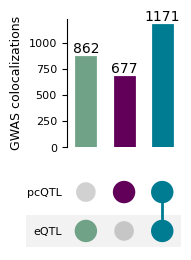

In [6]:
plt.rcParams.update({'font.size': 10})

pph4['pcQTL'] = pph4['PP.H4.abf_pc'] > coloc_cutoff
pph4['eQTL'] = pph4['PP.H4.abf_e'] > coloc_cutoff
upset = pph4[~(pph4['coloc_color']=='Neither')].set_index('eQTL').set_index('pcQTL', append=True)
fig = plt.figure(figsize=(2,3))
upset = up.UpSet(upset, intersection_plot_elements=3, totals_plot_elements = 0, show_counts=True, element_size=None)  # disable the default bar chart
#upset.add_stacked_bars(by="multiple_e_color_label", title="Count", elements=4, colors=('lightgrey', '#67AFD2','#016895'))
upset.style_subsets(present=["eQTL"], absent=["pcQTL"], facecolor=qtl_palette['eQTL only'], linewidth=2)
upset.style_subsets(present=["pcQTL"], absent=["eQTL"], facecolor=qtl_palette['pcQTL only'], linewidth=2)
upset.style_subsets(present=["eQTL", "pcQTL"], facecolor=qtl_palette['Both'], linewidth=2)

# style the instersection plot
plot_result = upset.plot(fig=fig)
print(plot_result.keys())

plot_result['intersections'].set_ylabel("GWAS colocalizations")

plt.savefig("/home/klawren/oak/pcqtls/workflow/main_figures/figures/figure_3_upset.pdf", transparent=True)
plt.grid(False)
plt.show()
plt.rcParams.update({'font.size': 7})

In [7]:
# load in variant-level aFC
pcqtl_afc = load_across_tissues(config, load_pc_afc)
eqqtl_afc = load_across_tissues(config, load_e_afc)
qtl_afc = pd.concat([pcqtl_afc, eqqtl_afc]).drop_duplicates(['tissue_id', 'pid', 'sid']).reset_index(drop=True)

# load in credible sets
pcqtl_susie = load_across_tissues(config, load_pc_susie)
pcqtl_susie['cluster_id'] = pcqtl_susie['phenotype_id'].str.split('_pc').str[0]
pcqtl_susie['gene_id'] = pcqtl_susie['cluster_id'].str.split('_')
eqtl_susie = load_across_tissues(config, load_e_susie)
eqtl_susie['cluster_id'] = eqtl_susie['phenotype_id'].str.split('_e').str[0]
eqtl_susie['gene_id'] = eqtl_susie['cluster_id'].str.split('_')
susie = pd.concat([pcqtl_susie, eqtl_susie], keys=['pcQTL', 'eQTL'], names=['qtl_type']).reset_index()
susie_explode = susie.explode('gene_id')

# merge in afc information
susie_explode_afc = pd.merge(susie_explode, qtl_afc[['pid', 'sid', 'tissue_id', 'log2_aFC']], left_on=['gene_id', 'variant_id', 'tissue_id'], 
    right_on=['pid', 'sid', 'tissue_id'], how='left')

# pip-weighted afc over credible set
susie_explode_afc['pip_afc'] = susie_explode_afc['pip'] * susie_explode_afc['log2_aFC']
credible_set_grouped_afc = susie_explode_afc.groupby(['phenotype_id', 'cs_id', 'tissue_id', 'gene_id', 'qtl_type']).agg({'pip_afc':'sum', 'pip':'sum'}).reset_index()
credible_set_grouped_afc['pip_afc_weighted'] = credible_set_grouped_afc['pip_afc']/credible_set_grouped_afc['pip']
credible_set_grouped_afc['abs_pip_afc_weighted'] = credible_set_grouped_afc['pip_afc_weighted'].abs()

# group over genes in a cluster that a credible set impacts
cluster_grouped_afc = credible_set_grouped_afc.groupby(['tissue_id', 'phenotype_id', 'cs_id', 'qtl_type']).agg(
    max_afc=('abs_pip_afc_weighted', 'max'),
    mean_afc=('abs_pip_afc_weighted', 'mean'), 
    std_afc=('abs_pip_afc_weighted', 'std')).reset_index()

cluster_grouped_afc['cv_afc'] = cluster_grouped_afc['std_afc']/cluster_grouped_afc['mean_afc'] * 100

In [8]:
# load in gwas signal groups
gwas_signal_groups = load_across_tissues(config, load_gwas_signal_groups)

gwas_signal_groups['phenotype_cs_id'] = gwas_signal_groups['signal_id'].str.split('-')
gwas_signal_groups_exploded = gwas_signal_groups.explode('phenotype_cs_id')

# get just the qtl phenotypes
gwas_signal_groups_qtl_pheno_exploded = gwas_signal_groups_exploded[~gwas_signal_groups_exploded['phenotype_cs_id'].str.contains('gwas')]
gwas_signal_groups_qtl_pheno_exploded['cs_id'] = gwas_signal_groups_qtl_pheno_exploded['phenotype_cs_id'].str.split('_cs_').str[1].str.split('_cluster').str[0].astype(int)
gwas_signal_groups_qtl_pheno_exploded['phenotype_id'] = gwas_signal_groups_qtl_pheno_exploded['phenotype_cs_id'].str.split('_cs_').str[0]

# merge in aFC information
gwas_signal_groups_afc = pd.merge(gwas_signal_groups_qtl_pheno_exploded, cluster_grouped_afc, on=['tissue_id', 'phenotype_id', 'cs_id'], how='left')
gwas_signal_groups_afc['has_gwas'] = gwas_signal_groups_afc['num_gwas_coloc'] > 0
gwas_signal_groups_afc = gwas_signal_groups_afc[~gwas_signal_groups_afc['max_afc'].isna()]

/local/scratch/klawren/slrmtmp.49273183/ipykernel_6401/2011412530.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gwas_signal_groups_qtl_pheno_exploded['cs_id'] = gwas_signal_groups_qtl_pheno_exploded['phenotype_cs_id'].str.split('_cs_').str[1].str.split('_cluster').str[0].astype(int)
/local/scratch/klawren/slrmtmp.49273183/ipykernel_6401/2011412530.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gwas_signal_groups_qtl_pheno_exploded['phenotype_id'] = gwas_signal_groups_qtl_pheno_exploded['phenotyp

In [9]:
# run a model looking at gwas pliotropy controling for egene effect size
X = gwas_signal_groups_afc[['cv_afc', 'max_afc']]
y = gwas_signal_groups_afc['has_gwas']
X = sm.add_constant(X)
model = sm.Logit(y, X).fit()
print(model.summary())
model.pvalues

Optimization terminated successfully.
         Current function value: 0.342929
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               has_gwas   No. Observations:                27625
Model:                          Logit   Df Residuals:                    27622
Method:                           MLE   Df Model:                            2
Date:                Tue, 18 Nov 2025   Pseudo R-squ.:                 0.01852
Time:                        12:10:07   Log-Likelihood:                -9473.4
converged:                       True   LL-Null:                       -9652.2
Covariance Type:            nonrobust   LLR p-value:                 2.306e-78
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.3883      0.046    -29.994      0.000      -1.479      -1.298
cv_afc        -0.0017      0.

const      1.169149e-197
cv_afc      7.733363e-04
max_afc     9.805860e-61
dtype: float64

In [10]:
example_signal_id = 'ENSG00000108511.9_ENSG00000120068.6_ENSG00000120075.5_ENSG00000120093.11_ENSG00000182742.5_ENSG00000260027.4_pc4_cs_2-gwas_GIANT_HEIGHT_cluster_ENSG00000108511.9_ENSG00000120068.6_ENSG00000120075.5_ENSG00000120093.11_ENSG00000182742.5_ENSG00000260027.4_cs_5'
example_cluster_id = 'ENSG00000108511.9_ENSG00000120068.6_ENSG00000120075.5_ENSG00000120093.11_ENSG00000182742.5_ENSG00000260027.4'
example_tissue_id = 'Esophagus_Muscularis'
example_cs_id = 'ENSG00000108511.9_ENSG00000120068.6_ENSG00000120075.5_ENSG00000120093.11_ENSG00000182742.5_ENSG00000260027.4_pc4_cs_2'
example_gwas_id = 'GIANT_HEIGHT_cs_5_cluster_ENSG00000108511.9_ENSG00000120068.6_ENSG00000120075.5_ENSG00000120093.11_ENSG00000182742.5_ENSG00000260027.4'
example_lead_variant_id = 'chr17_48584210_C_T_b38'

In [11]:
susie_annotated = load_susie_annotated(config, example_tissue_id)
gwas_signals = load_across_tissues(config, load_gwas_signal_groups)

In [ ]:
example_coloc = gwas_signals[gwas_signals['signal_id'] == example_signal_id].iloc[0]
example_cs = susie_annotated[susie_annotated['cs_id'] == example_cs_id]
example_var = example_cs.iloc[0]

In [13]:
# bring in the nominal p values
nominal_e = load_e_nominal(config, example_var['tissue_id'], example_var['chr'])
nominal_pc = load_pc_nominal(config, example_var['tissue_id'], example_var['chr'])

# bring in gwas summary stats
gwas_path = '/oak/stanford/groups/smontgom/shared/gwas_summary_stats/barbeira_gtex_imputed/imputed_gwas_hg38_1.1/imputed_GIANT_HEIGHT.txt.gz'
example_gwas = pd.read_csv(gwas_path, sep='\t')

pc4_pvalues = nominal_pc[(nominal_pc['cluster_id'] == example_coloc['cluster_id']) & (nominal_pc['pc_num']==4)][['variant_id', 'pval_nominal']]
gwas_pc4_pvalues_merged = pd.merge(pc4_pvalues, example_gwas[['panel_variant_id', 'pvalue']], left_on='variant_id', right_on='panel_variant_id', how='inner')

pc loadings

In [14]:
qtl_slopes = example_cs['egene_qtl_slope'].apply(ast.literal_eval).values
pip_weighted_qtl_slopes = np.asarray([np.asarray(qtl_slopes[i])*example_cs['pip'].iloc[i] for i in range(len(qtl_slopes))])
pip_weighted_qtl_slopes = pip_weighted_qtl_slopes.sum(axis=0)/example_cs['pip'].sum()

hox_cluster_loadings = pd.DataFrame({'beta':pip_weighted_qtl_slopes, 
              'loading':ast.literal_eval(example_cs['egene_pc_slope'].iloc[0]), 
              'egene_id':['HOXB4', 'HOXB3', 'HOXB5', 'HOXB6', 'HOXB8', 'HOXB7']})
hox_cluster_loadings['loading'] = hox_cluster_loadings['loading']*-1


/local/scratch/klawren/slrmtmp.49273183/ipykernel_6401/4173052072.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_violin1.set_xticklabels(['No GWAS', 'Has GWAS'])


True, False p=2.00e-73


/local/scratch/klawren/slrmtmp.49273183/ipykernel_6401/4173052072.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_violin2.set_xticklabels(['No GWAS', 'Has GWAS'])
/local/scratch/klawren/slrmtmp.49273183/ipykernel_6401/4173052072.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/local/scratch/klawren/slrmtmp.49273183/ipykernel_6401/4173052072.py:124: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


True, False p=7.26e-07


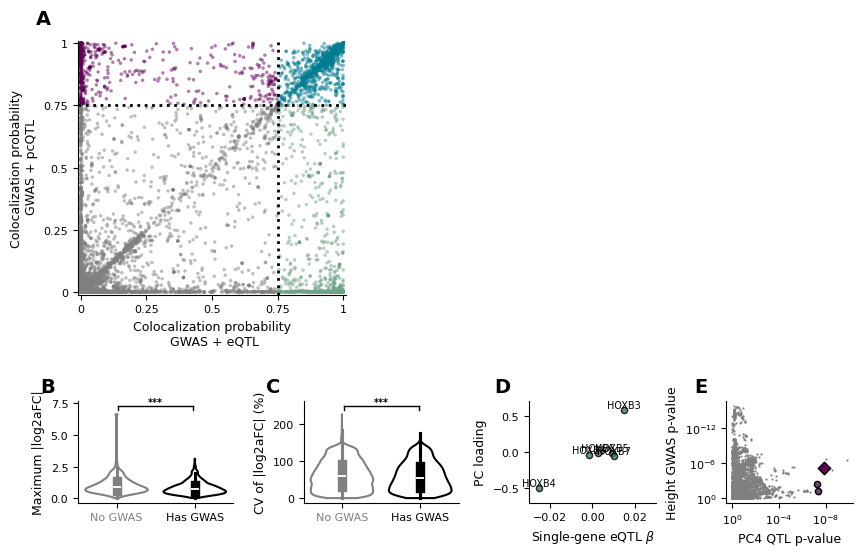

In [15]:
# Create large figure panel with custom grid layout
fig = plt.figure(figsize=(10, 6), constrained_layout=True)

# Create grid layout: 2 rows, 5 columns (scatter plot spans 2 columns)
gs = fig.add_gridspec(2, 6, hspace=.6, wspace=1, width_ratios=[1, 1, 1, 1, 3, 3], height_ratios=[2.5, 1] )

# Panel A: Scatter plot (PPH4 GWAS-pcQTL vs GWAS-eQTL) - Upper Left (spans 2 columns)
ax_scatter = fig.add_subplot(gs[0, :3])
sns.scatterplot(pph4[pph4['coloc_color'].isin(['Neither', 'Both', 'eQTL only', 'pcQTL only'])], 
                x='PP.H4.abf_e', y='PP.H4.abf_pc', hue='coloc_color', ax=ax_scatter, s=5, alpha=.5,
                palette=qtl_palette, edgecolor=None,
                hue_order=['Neither', 'Both', 'eQTL only', 'pcQTL only'], legend=False)
ax_scatter.axhline(.75, color='k', linestyle=':', linewidth=2)
ax_scatter.axvline(.75, color='k', linestyle=':', linewidth=2)
ax_scatter.set_xlabel('Colocalization probability\n GWAS + eQTL')
ax_scatter.set_ylabel('Colocalization probability\n GWAS + pcQTL')
ax_scatter.set_xlim(-.01, 1.01)
ax_scatter.set_ylim(-.01, 1.01)
ax_scatter.set_xticks([0, .25, .5, .75, 1])
ax_scatter.set_xticklabels([0, .25, .5, .75, 1])
ax_scatter.set_yticks([0, .25, .5, .75, 1])
ax_scatter.set_yticklabels([0, .25, .5, .75, 1])
ax_scatter.spines['top'].set_visible(False)
ax_scatter.spines['right'].set_visible(False)

# Add panel label A in corner
ax_scatter.text(-0.1, 1.05, 'A', transform=ax_scatter.transAxes, fontsize=14, fontweight='bold', 
                ha='right', va='bottom')

# Upper Right: Left blank as requested (spans columns 2-4)
# No subplot needed for blank area

# Bottom row: Four plots arranged horizontally (each spans 1 column)
# Panel B: Maximum single-gene abs(aFC) violin plot - Bottom Left
ax_violin1 = fig.add_subplot(gs[1, 0:2])
sns.violinplot(data=gwas_signal_groups_afc, x='has_gwas', y='max_afc',
               hue='has_gwas', palette=['grey', 'k'], ax=ax_violin1, cut=0,
               inner='box', linewidth=1.5, saturation=0.8, fill=False, legend=False)
ax_violin1.spines[['right', 'top']].set_visible(False)
ax_violin1.set_ylabel('Maximum |log2aFC|')
ax_violin1.set_xlabel('')
ax_violin1.set_xticklabels(['No GWAS', 'Has GWAS'])

# Add statistical significance bar
add_statistical_significance(ax_violin1, gwas_signal_groups_afc, 'has_gwas', 'max_afc', palette=['grey', 'k'])

# Color the x-axis tick labels to match the palette
for i, tick_label in enumerate(ax_violin1.get_xticklabels()):
    if i == 0:  # No GWAS
        tick_label.set_color('grey')
    else:  # Has GWAS
        tick_label.set_color('k')

# Add panel label B in corner
ax_violin1.text(-0.15, 1.05, 'B', transform=ax_violin1.transAxes, fontsize=14, fontweight='bold', 
                ha='right', va='bottom')

# Panel C: CV of abs(aFC) violin plot - Second from left
ax_violin2 = fig.add_subplot(gs[1, 2:4])
sns.violinplot(data=gwas_signal_groups_afc, x='has_gwas', y='cv_afc',
               hue='has_gwas', palette=['grey', 'k'], ax=ax_violin2, cut=0,
               inner='box', linewidth=1.5, saturation=0.8, fill=False, legend=False)
ax_violin2.spines[['right', 'top']].set_visible(False)
ax_violin2.set_ylabel('CV of |log2aFC| (%)')
ax_violin2.set_xlabel('')
ax_violin2.set_xticklabels(['No GWAS', 'Has GWAS'])

# Add statistical significance bar
add_statistical_significance(ax_violin2, gwas_signal_groups_afc, 'has_gwas', 'cv_afc', palette=['grey', 'k'])

# Color the x-axis tick labels to match the palette
for i, tick_label in enumerate(ax_violin2.get_xticklabels()):
    if i == 0:  # No GWAS
        tick_label.set_color('grey')
    else:  # Has GWAS
        tick_label.set_color('k')

# Add panel label C in corner
ax_violin2.text(-0.15, 1.05, 'C', transform=ax_violin2.transAxes, fontsize=14, fontweight='bold', 
                ha='right', va='bottom')

# Panel D: PC loadings plot
ax_pc = fig.add_subplot(gs[1, 4:5])


sns.scatterplot(hox_cluster_loadings, y='loading', x='beta', s=20, linewidth=1, edgecolor='k', 
                color='#417865', alpha=.8, ax=ax_pc, legend=False)
# Add gene labels above each point
for i, row in hox_cluster_loadings.iterrows():
    ax_pc.text(row['beta'], row['loading'], row['egene_id'], 
               ha='center', va='bottom')

ax_pc.spines[['right', 'top']].set_visible(False)
ax_pc.set_ylabel('PC loading')
ax_pc.set_xlabel('Single-gene eQTL '+r'$\beta$')
ax_pc.set_ylim([-.7, .7])
ax_pc.set_xlim([-.03, .03])

# Add panel label D in corner
ax_pc.text(-0.15, 1.05, 'D', transform=ax_pc.transAxes, fontsize=14, fontweight='bold', 
           ha='right', va='bottom')

# Panel E: Nominal p-values plot
ax_pvalues = fig.add_subplot(gs[1, 5:6])

sns.scatterplot(gwas_pc4_pvalues_merged, x='pval_nominal', y='pvalue', s=2, alpha=1, edgecolor=None, ax=ax_pvalues, color='grey')
sns.scatterplot(gwas_pc4_pvalues_merged[gwas_pc4_pvalues_merged['variant_id'].isin(example_cs['variant_id'])], x='pval_nominal', y='pvalue', s=20, alpha=1, linewidth=1, edgecolor='k', ax=ax_pvalues, color='#734675')
sns.scatterplot(gwas_pc4_pvalues_merged[gwas_pc4_pvalues_merged['variant_id'].isin([example_lead_variant_id])], x='pval_nominal', y='pvalue', s=40, alpha=1, linewidth=1, edgecolor='k', ax=ax_pvalues, color='#620059', marker='D')

ax_pvalues.invert_xaxis()
ax_pvalues.invert_yaxis()
ax_pvalues.set_xscale('log')
ax_pvalues.set_yscale('log')
ax_pvalues.spines[['right', 'top']].set_visible(False)
ax_pvalues.set_xlabel('PC4 QTL p-value')
ax_pvalues.set_ylabel('Height GWAS p-value')
ax_pvalues.set_xticks([1e0, 1e-4, 1e-8])
ax_pvalues.set_yticks([1e0, 1e-6, 1e-12])

# Add panel label E in corner
ax_pvalues.text(-0.15, 1.05, 'E', transform=ax_pvalues.transAxes, fontsize=14, fontweight='bold', 
                ha='right', va='bottom')

plt.tight_layout()

# Save the complete figure
plt.savefig("/home/klawren/oak/pcqtls/workflow/main_figures/figures/figure_3_combined.pdf", 
            transparent=True, dpi=300, bbox_inches='tight')
plt.show()